## שלב 1: טעינת נתונים וניקוי ראשוני  

⸻

## 📊 תחילת פרויקט: ניתוח כלכלי של תושבים לפי מאפיינים דמוגרפיים

🎯 תיאור כללי של הפרויקט

מטרת תרגיל זה היא להדגים תהליך של עיבוד נתונים, ניתוח מתקדם, והפקת תובנות עסקיות מתוך מידע כלכלי ודמוגרפי של תושבים.
התהליך כולל:
	•	טיוב והכנה של הנתונים
	•	ניתוח תכונות (features)
	•	ביצוע שאילתות מתקדמות
	•	הצגת מסקנות והצעות לפעולה
	•	בניית מודל חיזוי על בסיס Use Case

🧾 מבנה הנתונים

הנתונים נאספו מקובץ HDFS:
hdfs://namenode:8020/data/datasetN3.txt

הקובץ כולל מידע על תושבים במגזרים שונים, עם עמודות כגון:
	•	age: גיל
	•	work_sector: מגזר תעסוקה (A, B, C…)
	•	salary: שכר חודשי
	•	savings: חסכונות
	•	food_expenses_month: הוצאות מזון
	•	other_expenses_month: הוצאות אחרות
	•	education_years: שנות לימוד
	•	economic_class: דירוג כלכלי בין 1 ל־7
	•	zip_code: אזור מגורים

⸻

🔄 שלב 1: ניקוי ועיבוד ראשוני של הנתונים
	•	SparkSession נוצר עם שם "SalaryAnalysisCleanStart".
	•	קובץ נטען מקובץ .csv על גבי HDFS.
	•	עמודת אינדקס (row  number) הוסרה, מאחר ואינה תורמת לניתוח.
	•	שמות עמודות נוקו והותאמו לתקני קוד – כולל הורדת רווחים, אותיות קטנות, הסרת סוגריים.
	•	בוצעה בדיקה לשורות ריקות לחלוטין – כלומר: כל התאים בהן null או מחרוזות ריקות.
	•	שורות ריקות הוסרו מה־DataFrame כדי למנוע השפעה על חישובים סטטיסטיים והסקות שגויות.

In [1]:
import os

# נכוון את Spark להשתמש בגרסת פייתון של Conda
os.environ["PYSPARK_PYTHON"] = "/opt/conda/envs/bigdata/bin/python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/opt/conda/envs/bigdata/bin/python"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SalaryAnalysis") \
    .getOrCreate()

# טוענים קובץ
df = spark.read.option("header", "true").csv("hdfs://namenode:8020/data/datasetN3.txt")
df.show(5)

+-----------+---+-----------+------+-------+---------------------+--------+----------------------+--------------+--------------+
|row  number|age|work sector|salery|savings|Food expenses (month)|zip code|other expenses (month)|educaion years|economic class|
+-----------+---+-----------+------+-------+---------------------+--------+----------------------+--------------+--------------+
|          1| 37|          B|  6643|  35501|                 1185|   24602|                  1958|            18|             5|
|          2| 35|          E|  7580|  28599|                 1960|   21555|                  1732|            19|             6|
|          3| 29|          B|  7612|  21559|                 1155|   31315|                  1294|            18|             7|
|          4| 52|          E|  6958|  44584|                 1760|   24157|                  1157|            17|             6|
|          5| 38|          D|  2818|   6724|                  470|   18148|                  1935

In [2]:
from pyspark.sql.functions import col
df_clean = df.drop("row  number")


# שינוי שמות העמודות – ניקוי רווחים והחלפת תווים בעייתיים
new_columns = [c.strip().lower().replace(" ", "_").replace("(", "").replace(")", "") for c in df_clean.columns]
df_clean = df_clean.toDF(*new_columns)

print(f"🔢 מספר השורות: {df_clean.count()}")

🔢 מספר השורות: 6000


In [3]:
from pyspark.sql.functions import col, trim
from functools import reduce

# תנאי שבודק אם כל התאים בשורה ריקים (null או מחרוזת ריקה)
empty_conditions = [(col(c).isNull() | (trim(col(c)) == "")) for c in df_clean.columns]
all_columns_empty = reduce(lambda a, b: a & b, empty_conditions)

# הצגת כמות שורות ריקות
empty_rows_count = df_clean.filter(all_columns_empty).count()
print(f"🧾 מספר שורות ריקות לגמרי: {empty_rows_count}")

# סינון החוצה של השורות הריקות לגמרי
df_clean = df_clean.filter(~all_columns_empty)

# הצגת מספר שורות לאחר הניקוי
print(f"✅ מספר שורות לאחר הסרת שורות ריקות לגמרי: {df_clean.count()}")

🧾 מספר שורות ריקות לגמרי: 14
✅ מספר שורות לאחר הסרת שורות ריקות לגמרי: 5986


## שלב 2: ניתוח חוסרים  


In [4]:
df_clean = df_clean.withColumnRenamed("salery", "salary") \
                   .withColumnRenamed("educaion_years", "education_years")

In [5]:
df_clean.printSchema()

root
 |-- age: string (nullable = true)
 |-- work_sector: string (nullable = true)
 |-- salary: string (nullable = true)
 |-- savings: string (nullable = true)
 |-- food_expenses_month: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- other_expenses_month: string (nullable = true)
 |-- education_years: string (nullable = true)
 |-- economic_class: string (nullable = true)



In [6]:
for column in df_clean.columns:
    decimal_count = df_clean.filter(col(column).rlike(r"\d+\.\d+")).count()
    if decimal_count > 0:
        print(f"✅ בעמודה '{column}' יש {decimal_count} ערכים עשרוניים.")
    else:
        print(f"❌ אין ערכים עשרוניים בעמודה '{column}'.")

❌ אין ערכים עשרוניים בעמודה 'age'.
❌ אין ערכים עשרוניים בעמודה 'work_sector'.
❌ אין ערכים עשרוניים בעמודה 'salary'.
❌ אין ערכים עשרוניים בעמודה 'savings'.
❌ אין ערכים עשרוניים בעמודה 'food_expenses_month'.
❌ אין ערכים עשרוניים בעמודה 'zip_code'.
❌ אין ערכים עשרוניים בעמודה 'other_expenses_month'.
❌ אין ערכים עשרוניים בעמודה 'education_years'.
❌ אין ערכים עשרוניים בעמודה 'economic_class'.


In [7]:
df_clean.show(10, truncate=False)

+---+-----------+------+-------+-------------------+--------+--------------------+---------------+--------------+
|age|work_sector|salary|savings|food_expenses_month|zip_code|other_expenses_month|education_years|economic_class|
+---+-----------+------+-------+-------------------+--------+--------------------+---------------+--------------+
|37 |B          |6643  |35501  |1185               |24602   |1958                |18             |5             |
|35 |E          |7580  |28599  |1960               |21555   |1732                |19             |6             |
|29 |B          |7612  |21559  |1155               |31315   |1294                |18             |7             |
|52 |E          |6958  |44584  |1760               |24157   |1157                |17             |6             |
|38 |D          |2818  |6724   |470                |18148   |1935                |10             |1             |
|48 |D          |2045  |3920   |468                |17673   |1360                |10    

## שלב 3: המרת סוגי עמודות  


In [8]:
from pyspark.sql.types import IntegerType

# עמודות מספריות שנרצה להמיר ל־int
int_columns = [
    "age", "salary", "savings",
    "food_expenses_month", "other_expenses_month",
    "education_years", "economic_class"
]

# המרה לעמודות מספריות
for col_name in int_columns:
    df_clean = df_clean.withColumn(col_name, col(col_name).cast(IntegerType()))

# בדיקת הסכימה לאחר ההמרה
df_clean.printSchema()

root
 |-- age: integer (nullable = true)
 |-- work_sector: string (nullable = true)
 |-- salary: integer (nullable = true)
 |-- savings: integer (nullable = true)
 |-- food_expenses_month: integer (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- other_expenses_month: integer (nullable = true)
 |-- education_years: integer (nullable = true)
 |-- economic_class: integer (nullable = true)



In [11]:
from pyspark.sql.functions import col, trim, when, count
import pandas as pd
import numpy as np

# סך השורות בדאטה
total_rows = df_clean.count()

# רשימת העמודות
columns = df_clean.columns

# ניצור DataFrame עם חישוב עבור כל עמודה: כמה ערכים חסרים
missing_info = (
    df_clean
    .select([
        count(when(col(c).isNull() | (trim(col(c)) == ""), c)).alias(c)
        for c in columns
    ])
    .toPandas()
    .T  # טרנספוזיציה - כל שורה תהיה עמודה מהמקור
    .reset_index()
)

# שינוי שמות עמודות
missing_info.columns = ["column", "missing_count"]

# חישוב אחוז החוסרים
missing_info["missing_percent"] = np.round((missing_info["missing_count"] / total_rows) * 100, 2)

# תצוגה מלאה
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# הדפסת התוצאה המסודרת לפי כמות חוסרים
missing_info = missing_info.sort_values(by="missing_count", ascending=False).reset_index(drop=True)
print(missing_info)

                 column  missing_count  missing_percent
0        economic_class             46             0.77
1                   age             18             0.30
2   food_expenses_month             18             0.30
3              zip_code             18             0.30
4  other_expenses_month             16             0.27
5       education_years             16             0.27
6           work_sector             11             0.18
7                salary              0             0.00
8               savings              0             0.00


In [15]:
df_clean.write \
   .option("header", "true") \
   .mode("overwrite") \
   .csv("hdfs://namenode:8020/data/df_clean_csv_v2")

## שלב 4: שאילתות ניתוחיות  


In [16]:
df_clean.filter(col("age") < 10).show()

+---+-----------+------+-------+-------------------+--------+--------------------+---------------+--------------+
|age|work_sector|salary|savings|food_expenses_month|zip_code|other_expenses_month|education_years|economic_class|
+---+-----------+------+-------+-------------------+--------+--------------------+---------------+--------------+
|  7|          E|  7467|  13635|               1718|   40154|                2010|             18|             6|
|  5|          B|  3743|   9148|               1249|   20753|                1649|             21|             3|
|  2|          D|  3817|   9190|                519|   20172|                2069|             12|             2|
|  6|          C|  3710|   8444|                747|   34675|                2269|             12|             2|
|  2|          E|  8488|  94033|               2238|   28462|                1574|             19|             7|
|  7|          B|  6156|   6582|               1390|   19161|                1026|      

## 🔢 הוספת פיצ’ר “עשירון שכר” (`salary_decile`)

בשלב זה הוספנו פיצ'ר חדש לעמודת השכר (`salary`) שנקרא `salary_decile`, ומדרג כל שורה בהתאם לעשירון שבו נמצא העובד מבחינת השכר באוכלוסייה.

---

### 📌 מטרת הפעולה

הוספת דירוג עשירוני מאפשרת:
- לחלק את העובדים לקבוצות שכר אחידות (1–10)
- לבצע ניתוחים סטטיסטיים ממוקדים לפי רמות שכר
- לבחון התנהגות כלכלית, רמת הוצאות, חסכונות או השכלה לפי קבוצות שכר
- ליצור ויזואליזציות נוחות, למשל השוואת חסכונות ממוצעים בין עשירונים

---

### 🧮 שיטת החישוב

- השתמשנו בפונקציה `approxQuantile()` של PySpark לחישוב גבולות עשירונים עבור עמודת `salary`.
- הפונקציה קיבלה את הנקודות הבאות:  
  `[0.1, 0.2, 0.3, ..., 1.0]`  
  כדי לחשב את הגבולות העליונים של כל אחד מהעשירונים.
- לאחר קבלת הגבולות, לכל שורה בדאטה שויכה עשירון (`1` עד `10`) לפי מיקום השכר שלה ביחס לנקודות שנקבעו.
- דירוג זה נשמר בעמודה חדשה בשם `salary_decile`.

---

### 🧪 דוגמה (לצורכי הסבר בלבד):

| salary | salary_decile |
|--------|----------------|
| 4,200  | 2              |
| 7,800  | 6              |
| 12,300 | 9              |

---

### 🛠 הערות טכניות

- `approxQuantile()` היא פונקציה יעילה לחישוב קוונטילים (quantiles) על דאטה גדול, עם שליטה על רמת הדיוק.
- בניגוד לפונקציות כמו `ntile()`, היא לא דורשת פעולה של `window`, ולכן מתאימה גם לדאטה גדול מאוד.

---

### 💡 שימושים עתידיים

העמודה `salary_decile` תשמש אותנו ל:
- חתכים בגרפים לפי קבוצות שכר
- חישוב ממוצעים והשוואות בין עשירונים
- קלט אפשרי למודל חיזוי, כאשר רוצים לתת משקל לרמת השכר של העובד

In [18]:
# נחשב גבולות עליונים של עשירונים (0.1, 0.2, ..., 1.0)
quantiles = df_clean.approxQuantile("salary", [x/10 for x in range(1, 11)], 0.01)

# הצגת ערכי העשירונים בפועל
for i, q in enumerate(quantiles, 1):
    print(f"עשירון {i}: {q}")

עשירון 1: 2575.0
עשירון 2: 3109.0
עשירון 3: 3530.0
עשירון 4: 4078.0
עשירון 5: 4890.0
עשירון 6: 5522.0
עשירון 7: 6725.0
עשירון 8: 7535.0
עשירון 9: 8148.0
עשירון 10: 10603.0


In [19]:
from pyspark.sql.functions import when

# נבנה תנאים לפי גבולות עשירון
decile_col = when(col("salary") <= quantiles[0], 1)

for i in range(1, 9):
    decile_col = decile_col.when(
        (col("salary") > quantiles[i-1]) & (col("salary") <= quantiles[i]), i + 1
    )

# עשירון אחרון
decile_col = decile_col.otherwise(10)

# הוספת עמודה
df_clean = df_clean.withColumn("salary_decile", decile_col)

df_clean.printSchema()
df_clean.show(10, truncate=False)

root
 |-- age: integer (nullable = true)
 |-- work_sector: string (nullable = true)
 |-- salary: integer (nullable = true)
 |-- savings: integer (nullable = true)
 |-- food_expenses_month: integer (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- other_expenses_month: integer (nullable = true)
 |-- education_years: integer (nullable = true)
 |-- economic_class: integer (nullable = true)
 |-- salary_decile: integer (nullable = false)

+---+-----------+------+-------+-------------------+--------+--------------------+---------------+--------------+-------------+
|age|work_sector|salary|savings|food_expenses_month|zip_code|other_expenses_month|education_years|economic_class|salary_decile|
+---+-----------+------+-------+-------------------+--------+--------------------+---------------+--------------+-------------+
|37 |B          |6643  |35501  |1185               |24602   |1958                |18             |5             |7            |
|35 |E          |7580  |28599  |1960 

In [20]:
from pyspark.sql.functions import col, count, round

# סך השורות בכל עשירון
total_per_decile = df_clean.groupBy("salary_decile").count().withColumnRenamed("count", "total_in_decile")

# סך הסקטורים בכל עשירון
sector_counts = df_clean.groupBy("salary_decile", "work_sector").count().withColumnRenamed("count", "sector_count")

# חיבור טבלת הסקטורים עם הסכום הכללי כדי לחשב אחוזים
sector_with_percent = sector_counts.join(total_per_decile, on="salary_decile")

# חישוב אחוז שכיחות של כל סקטור באותו עשירון
sector_with_percent = sector_with_percent.withColumn(
    "sector_percent", round((col("sector_count") / col("total_in_decile")) * 100, 2)
)

# מיון לצפייה נוחה
sector_with_percent.orderBy("salary_decile", "sector_percent", ascending=[True, False]).show(100, truncate=False)

+-------------+-----------+------------+---------------+--------------+
|salary_decile|work_sector|sector_count|total_in_decile|sector_percent|
+-------------+-----------+------------+---------------+--------------+
|1            |D          |619         |634            |97.63         |
|1            |C          |13          |634            |2.05          |
|1            |NULL       |2           |634            |0.32          |
|2            |D          |302         |505            |59.8          |
|2            |C          |200         |505            |39.6          |
|2            |NULL       |3           |505            |0.59          |
|3            |C          |483         |627            |77.03         |
|3            |D          |142         |627            |22.65         |
|3            |A          |2           |627            |0.32          |
|4            |C          |503         |616            |81.66         |
|4            |D          |65          |616            |10.55   

In [ ]:
sector_with_percent.write \
    .option("header", "true") \
    .mode("overwrite") \
    .csv("hdfs://namenode:8020/output/sector_with_percent")

In [21]:
from pyspark.sql.functions import avg, stddev, round

df_clean.groupBy("salary_decile") \
    .agg(
        round(avg("education_years"), 2).alias("avg_education_years"),
        round(stddev("education_years"), 2).alias("std_education_years")
    ) \
    .orderBy("salary_decile") \
    .show()

+-------------+-------------------+-------------------+
|salary_decile|avg_education_years|std_education_years|
+-------------+-------------------+-------------------+
|            1|              12.59|                2.0|
|            2|              13.21|               2.17|
|            3|              14.03|               2.29|
|            4|               14.4|               2.24|
|            5|              16.04|               2.23|
|            6|              16.58|               1.91|
|            7|              17.22|               1.99|
|            8|              17.89|               2.05|
|            9|              18.13|               2.05|
|           10|              18.15|               2.24|
+-------------+-------------------+-------------------+



In [22]:
from pyspark.sql.functions import avg, round

avg_edu_by_sector = df_clean.filter("work_sector IS NOT NULL") \
    .groupBy("work_sector") \
    .agg(round(avg("education_years"), 2).alias("avg_education_years")) \
    .orderBy("avg_education_years", ascending=False)

avg_edu_by_sector.show()

+-----------+-------------------+
|work_sector|avg_education_years|
+-----------+-------------------+
|          E|              18.45|
|          B|              17.45|
|          A|              16.48|
|          C|              14.42|
|          D|               12.5|
+-----------+-------------------+



In [24]:
from pyspark.sql.functions import avg, round

# שמירת התוצאה לתוך DataFrame חדש
avg_edu_by_decile = df_clean.groupBy("salary_decile") \
    .agg(round(avg("education_years"), 2).alias("avg_education_years")) \
    .orderBy("salary_decile")



In [25]:
from pyspark.sql.functions import count, round, avg

# סך האנשים בכל סקטור
sector_total = df_clean.groupBy("work_sector").count().withColumnRenamed("count", "sector_total")

# כמה אנשים בכל שילוב של סקטור ועשירון
sector_decile_counts = df_clean.groupBy("work_sector", "salary_decile").count().withColumnRenamed("count", "count_in_decile")

# חישוב אחוזים: נחבר את סך האנשים לסקטור
sector_distribution = sector_decile_counts.join(sector_total, on="work_sector")

# הוספת אחוז מהעובדים בסקטור בעשירון
sector_distribution = sector_distribution.withColumn(
    "percent_in_sector",
    round((sector_distribution["count_in_decile"] / sector_distribution["sector_total"]) * 100, 2)
)

# נוסיף גם את ממוצע שנות הלימוד לכל סקטור
sector_education_avg = df_clean.groupBy("work_sector").agg(
    round(avg("education_years"), 2).alias("avg_education_years")
)

# צירוף של המידע לטבלה אחת
final_df = sector_distribution.join(sector_education_avg, on="work_sector")

# תצוגה מסודרת
final_df.orderBy("work_sector", "salary_decile").show(100, truncate=False)

+-----------+-------------+---------------+------------+-----------------+-------------------+
|work_sector|salary_decile|count_in_decile|sector_total|percent_in_sector|avg_education_years|
+-----------+-------------+---------------+------------+-----------------+-------------------+
|A          |3            |2              |1178        |0.17             |16.48              |
|A          |4            |43             |1178        |3.65             |16.48              |
|A          |5            |452            |1178        |38.37            |16.48              |
|A          |6            |512            |1178        |43.46            |16.48              |
|A          |7            |168            |1178        |14.26            |16.48              |
|A          |8            |1              |1178        |0.08             |16.48              |
|B          |4            |4              |1193        |0.34             |17.45              |
|B          |5            |18             |1193   

In [26]:
# בוחרים רק את העמודות הדרושות
sector_salary_edu_summary = final_df.select(
    "work_sector", 
    "salary_decile", 
    "count_in_decile", 
    "sector_total", 
    "percent_in_sector", 
    "avg_education_years"
)

# שמירה ל-HDFS


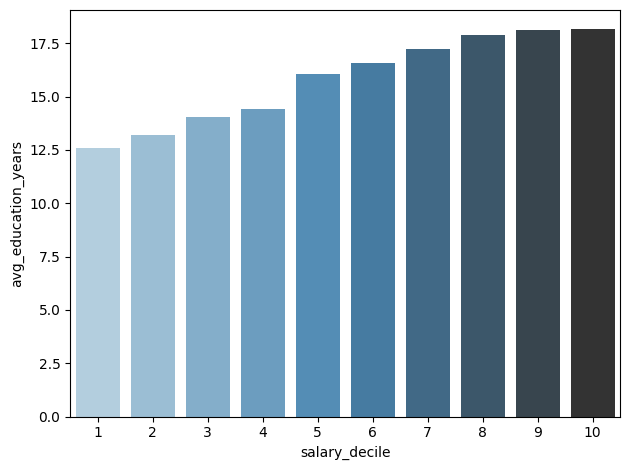

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# ממירים את הטבלה הרלוונטית לפנדס
edu_by_decile = df_clean.groupBy("salary_decile") \
    .agg(round(avg("education_years"), 2).alias("avg_education_years")) \
    .orderBy("salary_decile") \
    .toPandas()

# ציור הגרף
sns.barplot(
    data=edu_by_decile,
    x="salary_decile",
    y="avg_education_years",
    hue="salary_decile",         # כדי שתוכל להשתמש בפלטת צבעים
    palette="Blues_d",
    legend=False                 # לא צריך מקרא, כי הערכים כבר מופיעים בציר ה-x
)
plt.tight_layout()
plt.show()

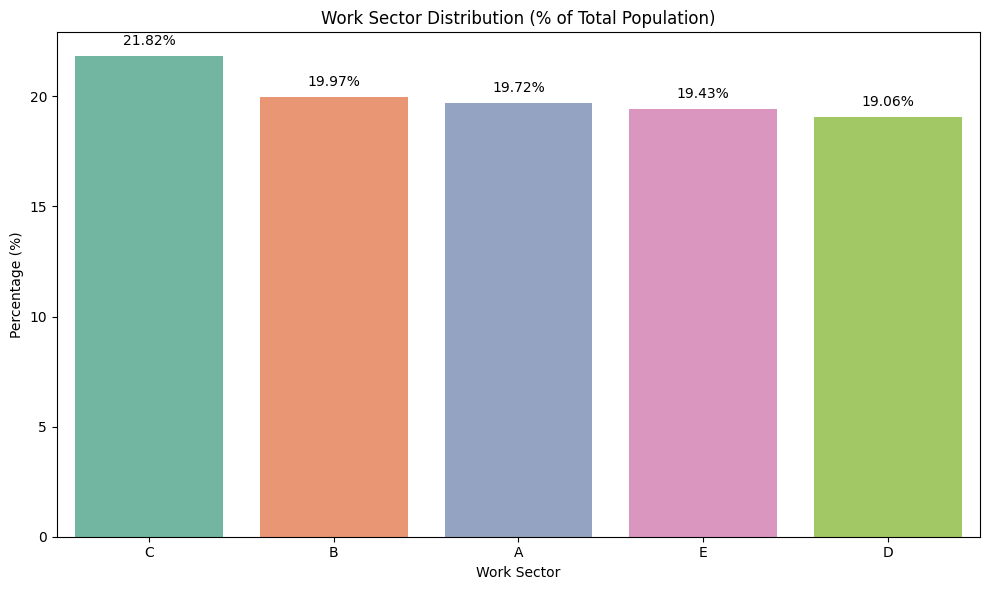

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# סינון ערכים חסרים (null) מתוך df_clean לפני groupBy
sector_freq = df_clean.filter(df_clean["work_sector"].isNotNull()) \
    .groupBy("work_sector") \
    .count() \
    .withColumnRenamed("count", "count_in_population") \
    .orderBy("count_in_population", ascending=False) \
    .toPandas()

# חישוב אחוזים
total_population = sector_freq["count_in_population"].sum()
sector_freq["percent"] = (sector_freq["count_in_population"] / total_population * 100).round(2)

# גרף
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=sector_freq,
    x="work_sector",
    y="percent",
    hue="work_sector",   # כך נפתרת התראת ה-FutureWarning
    palette="Set2",
    legend=False         # שלא יוצג מקרא מיותר
)

# הוספת תוויות אחוזים על כל עמודה
for index, row in sector_freq.iterrows():
    barplot.text(
        x=index,
        y=row["percent"] + 0.5,
        s=f'{row["percent"]}%',
        ha='center',
        fontsize=10
    )

# כותרות באנגלית
plt.title("Work Sector Distribution (% of Total Population)")
plt.xlabel("Work Sector")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

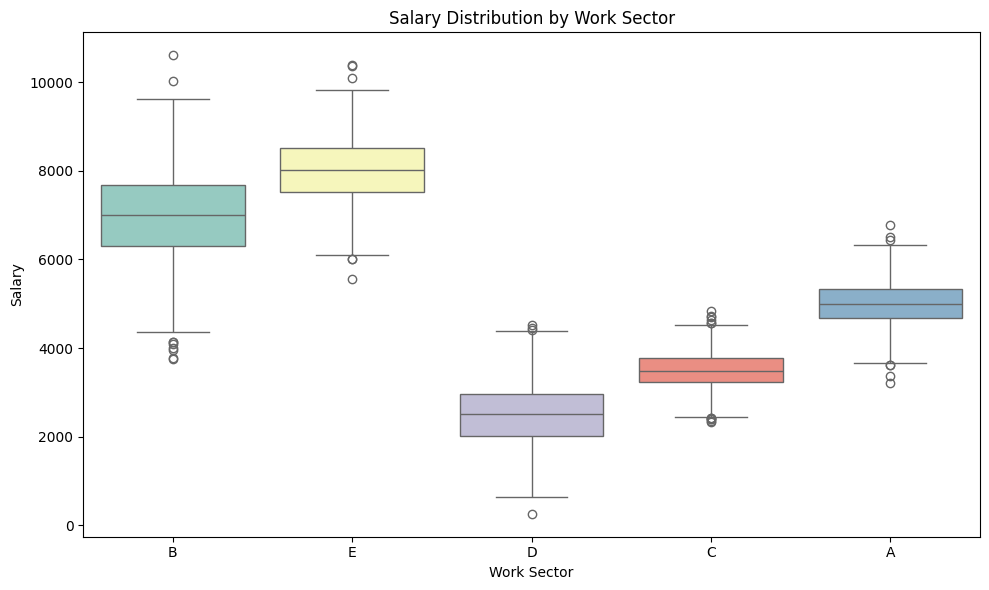

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# המרה ל-Pandas
df_pandas = df_clean.select("work_sector", "salary").dropna().toPandas()

# לוודא שהשכר מספרי
df_pandas["salary"] = pd.to_numeric(df_pandas["salary"], errors="coerce")

# הסרת ערכים חסרים
df_pandas = df_pandas.dropna(subset=["salary", "work_sector"])

# ציור Boxplot מתוקן
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_pandas,
    x="work_sector",
    y="salary",
    hue="work_sector",     # נדרש למניעת FutureWarning
    palette="Set3",
    legend=False           # לא נדרש מקרא מיותר
)

plt.title("Salary Distribution by Work Sector")
plt.xlabel("Work Sector")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [30]:
# 1. קריאת הטבלה מה-HDFS
df_sector = spark.read.csv("/output/sector_with_percent/part-00000-*.csv", header=True, inferSchema=True)

# 2. סינון שורות ריקות (סקטור NULL)
df_sector = df_sector.filter(df_sector["work_sector"].isNotNull())

# 3. הצגת דגימה
df_sector.show(10, truncate=False)

+-------------+-----------+------------+---------------+--------------+
|salary_decile|work_sector|sector_count|total_in_decile|sector_percent|
+-------------+-----------+------------+---------------+--------------+
|1            |C          |13          |634            |2.05          |
|1            |D          |619         |634            |97.63         |
|6            |A          |512         |588            |87.07         |
|6            |B          |75          |588            |12.76         |
|3            |A          |2           |627            |0.32          |
|3            |D          |142         |627            |22.65         |
|3            |C          |483         |627            |77.03         |
|5            |A          |452         |586            |77.13         |
|5            |C          |105         |586            |17.92         |
|5            |B          |18          |586            |3.07          |
+-------------+-----------+------------+---------------+--------

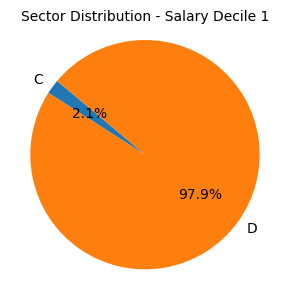

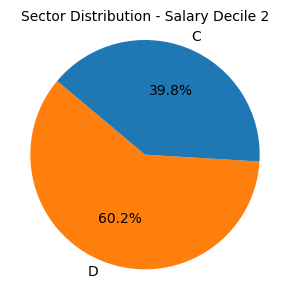

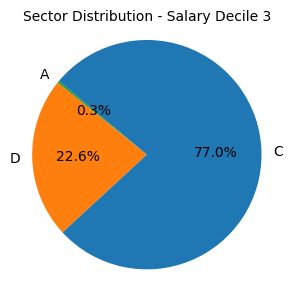

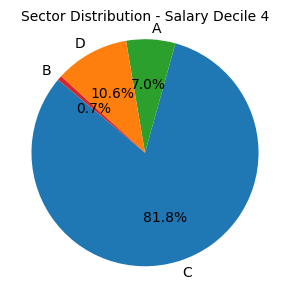

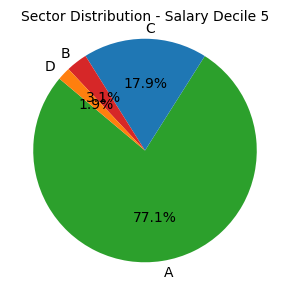

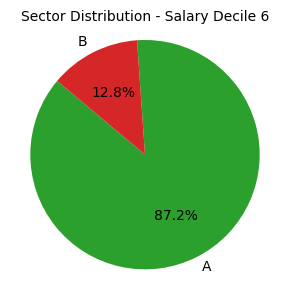

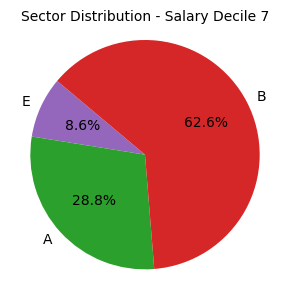

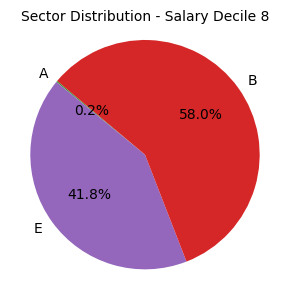

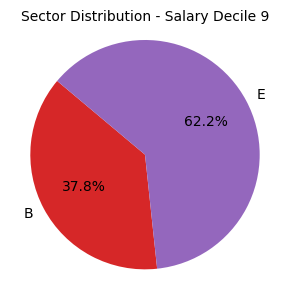

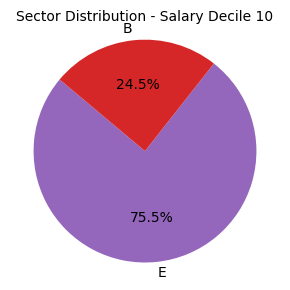

In [38]:
import matplotlib.pyplot as plt

unique_sectors = df_sector_pd["work_sector"].unique()
base_colors = plt.cm.tab10.colors  # צבעים בסיסיים

sector_colors = {
    sector: f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}"
    for sector, (r, g, b) in zip(unique_sectors, base_colors)
}

# המרת PySpark DataFrame ל־Pandas
df_sector_pd = df_sector.toPandas()

# שליפת כל העשירונים הקיימים
unique_deciles = sorted(df_sector_pd["salary_decile"].unique())

# לולאה על כל עשירון
for decile in unique_deciles:
    decile_data = df_sector_pd[df_sector_pd["salary_decile"] == decile]
    
    colors = [sector_colors.get(sector, "#999999") for sector in decile_data["work_sector"]]
    
    plt.figure(figsize=(3, 3))  # עוגת פאי קטנה
    plt.pie(
        decile_data["sector_percent"],
        labels=decile_data["work_sector"],
        autopct="%1.1f%%",
        startangle=140,
        colors=colors
    )
    plt.title(f"Sector Distribution - Salary Decile {decile}", fontsize=10)
    plt.axis("equal")
    plt.tight_layout()
    
    # אפשרות לשמירה (אם רוצים):
    # plt.savefig(f"sector_pie_decile_{decile}.png")

    plt.show()

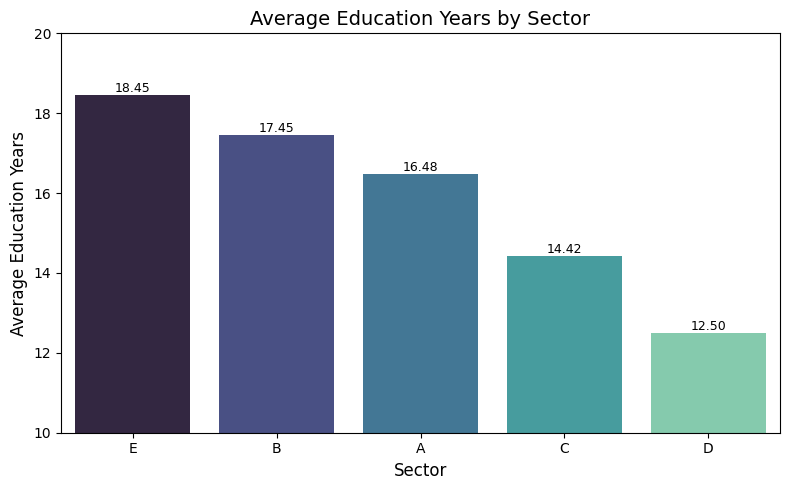

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# יצירת הנתונים (שמות באנגלית)
data = {
    "Sector": ["E", "B", "A", "C", "D"],
    "Average_Education_Years": [18.45, 17.45, 16.48, 14.42, 12.5]
}

df = pd.DataFrame(data)

# ציור הגרף
plt.figure(figsize=(8, 5))
barplot = sns.barplot(
    data=df,
    x="Sector",
    y="Average_Education_Years",
    hue="Sector",         # נדרש למניעת האזהרה על palette
    legend=False,
    palette="mako"
)

# הוספת ערכים על העמודות
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.2f}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9)

# כותרות
plt.title("Average Education Years by Sector", fontsize=14)
plt.xlabel("Sector", fontsize=12)
plt.ylabel("Average Education Years", fontsize=12)
plt.ylim(10, 20)
plt.tight_layout()
plt.show()

In [39]:
from pyspark.sql.functions import col, when, count

df_clean.select([
    count(when(col("education_years").isNull(), True)).alias("missing_education_years"),
    count(when(col("work_sector").isNull(), True)).alias("missing_work_sector")
]).show()

+-----------------------+-------------------+
|missing_education_years|missing_work_sector|
+-----------------------+-------------------+
|                     16|                 11|
+-----------------------+-------------------+



In [40]:
df_missing_filled = df_clean  # שמירה על df_clean המקורי, ועבודה על עותק

In [41]:
from pyspark.sql.functions import avg, round

edu_avg = df_missing_filled.groupBy("work_sector", "salary_decile") \
    .agg(round(avg("education_years"), 2).alias("avg_edu_sector_decile"))

In [42]:
df_missing_filled = df_missing_filled.join(
    edu_avg,
    on=["work_sector", "salary_decile"],
    how="left"
)

In [43]:
from pyspark.sql.functions import when, col, round as spark_round

# שלב 1: ניצור עמודה חדשה של שנות לימוד ממולאות לפי ממוצע
df_missing_filled = df_missing_filled.withColumn(
    "education_years_filled_raw",
    when(
        col("education_years").isNull(),
        col("avg_edu_sector_decile")
    ).otherwise(col("education_years"))
)

# שלב 2: נבצע עיגול למספר השלם הקרוב
df_missing_filled = df_missing_filled.withColumn(
    "education_years_filled",
    spark_round(col("education_years_filled_raw"))
)

In [44]:
from pyspark.sql.functions import col, count, when

df_missing_filled.select(
    count(when(col("education_years").isNull(), True)).alias("missing_before"),
    count(when(col("education_years_filled").isNull(), True)).alias("missing_after")
).show()

+--------------+-------------+
|missing_before|missing_after|
+--------------+-------------+
|            16|            0|
+--------------+-------------+



In [45]:
df_missing_filled.filter(col("education_years").isNull()) \
    .select("work_sector", "salary_decile", "avg_edu_sector_decile", "education_years_filled") \
    .show(10)

+-----------+-------------+---------------------+----------------------+
|work_sector|salary_decile|avg_edu_sector_decile|education_years_filled|
+-----------+-------------+---------------------+----------------------+
|          E|           10|                18.46|                  18.0|
|          D|            2|                12.48|                  12.0|
|          C|            5|                14.34|                  14.0|
|          D|            1|                12.55|                  13.0|
|          D|            2|                12.48|                  12.0|
|          D|            1|                12.55|                  13.0|
|          C|            3|                14.46|                  14.0|
|          D|            1|                12.55|                  13.0|
|          E|           10|                18.46|                  18.0|
|          C|            3|                14.46|                  14.0|
+-----------+-------------+---------------------+--

In [46]:
from pyspark.sql.functions import count

# טבלה עם הסקטור הכי נפוץ לכל צירוף של decile ו-years
sector_mode_df = df_missing_filled.groupBy("salary_decile", "education_years_filled", "work_sector") \
    .agg(count("*").alias("count")) \
    .orderBy("salary_decile", "education_years_filled", "count", ascending=[True, True, False])

# נשתמש ב-window כדי לשמור רק את הסקטור הנפוץ ביותר
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

window_spec = Window.partitionBy("salary_decile", "education_years_filled").orderBy(col("count").desc())

sector_mode_ranked = sector_mode_df.withColumn("rank", row_number().over(window_spec)) \
    .filter(col("rank") == 1) \
    .select("salary_decile", "education_years_filled", "work_sector") \
    .withColumnRenamed("work_sector", "most_common_sector")

In [47]:
df_with_most_common_sector = df_missing_filled.join(
    sector_mode_ranked,
    on=["salary_decile", "education_years_filled"],
    how="left"
)

In [48]:
from pyspark.sql.functions import when

df_with_filled_sector = df_with_most_common_sector.withColumn(
    "work_sector_filled",
    when(col("work_sector").isNull(), col("most_common_sector"))
    .otherwise(col("work_sector"))
)

In [49]:
from pyspark.sql.functions import col

# כמה רשומות היו חסרות ב-work_sector וקיבלו ערך ב-work_sector_filled
filled_count = df_with_filled_sector.filter(
    col("work_sector").isNull() & col("work_sector_filled").isNotNull()
).count()

print(f"מולאו {filled_count} ערכים חסרים בעמודת work_sector")

מולאו 11 ערכים חסרים בעמודת work_sector


In [50]:
df_with_filled_sector.filter(
    col("work_sector").isNull() & col("work_sector_filled").isNotNull()
).select(
    "salary_decile",
    "education_years_filled",
    "work_sector_filled"
).show(20, truncate=False)

+-------------+----------------------+------------------+
|salary_decile|education_years_filled|work_sector_filled|
+-------------+----------------------+------------------+
|7            |18.0                  |B                 |
|1            |12.0                  |D                 |
|10           |20.0                  |E                 |
|1            |13.0                  |D                 |
|2            |11.0                  |D                 |
|6            |16.0                  |A                 |
|4            |14.0                  |C                 |
|2            |15.0                  |C                 |
|7            |17.0                  |B                 |
|2            |13.0                  |D                 |
|8            |19.0                  |B                 |
+-------------+----------------------+------------------+



In [51]:
from pyspark.sql.functions import col, sum as spark_sum, when
import pandas as pd

# מספר השורות הכולל בדאטהפריים
total_rows = df_with_filled_sector.count()

# סופרים את כמות הערכים החסרים בכל עמודה
missing_counts = df_with_filled_sector.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_with_filled_sector.columns
])

# ממירים ל־Pandas ומסדרים את הפלט
missing_df = missing_counts.toPandas().T
missing_df.columns = ["missing_count"]
missing_df["missing_percent"] = (missing_df["missing_count"] / total_rows * 100).round(2)

# מסדרים את הפלט לפי אחוזים יורדים
missing_df = missing_df.sort_values("missing_percent", ascending=False)
missing_df.index.name = "column_name"
missing_df.reset_index(inplace=True)

# מציגים טבלה מסודרת
import seaborn as sns
import matplotlib.pyplot as plt



# מציג גם טבלה אם תרצה
missing_df.style.background_gradient(cmap='Blues').format({"missing_percent": "{:.2f}%", "missing_count": "{:.0f}"})

,column_name,missing_count,missing_percent
0,economic_class,46,0.77%
1,age,18,0.30%
2,food_expenses_month,18,0.30%
3,zip_code,18,0.30%
4,other_expenses_month,16,0.27%
5,education_years,16,0.27%
6,work_sector,11,0.18%
7,avg_edu_sector_decile,11,0.18%
8,salary_decile,0,0.00%
9,education_years_filled,0,0.00%


In [52]:
# נגדיר את שמות העמודות שהוחלפו ולכן אין צורך בהן יותר בניתוח החוסרים
replaced_columns = ["education_years", "work_sector", "avg_edu_sector_decile"]

# נמחק מהטבלה את השורות שמייצגות את העמודות האלו
missing_df_cleaned = missing_df[~missing_df["column_name"].isin(replaced_columns)].reset_index(drop=True)

# מציגים את התוצאה
missing_df_cleaned.style.background_gradient(cmap='Blues').format({"missing_percent": "{:.2f}%", "missing_count": "{:.0f}"})

,column_name,missing_count,missing_percent
0,economic_class,46,0.77%
1,age,18,0.30%
2,food_expenses_month,18,0.30%
3,zip_code,18,0.30%
4,other_expenses_month,16,0.27%
5,salary_decile,0,0.00%
6,education_years_filled,0,0.00%
7,salary,0,0.00%
8,savings,0,0.00%
9,education_years_filled_raw,0,0.00%


In [53]:
from pyspark.ml.feature import StringIndexer

# שלב 1: התאמה (fitting) של ה-StringIndexer
sector_indexer = StringIndexer(
    inputCol="work_sector_filled",
    outputCol="work_sector_index",
    handleInvalid="keep"
)

# מריצים ומקבלים DataFrame חדש עם work_sector_index
df_with_indexed_sector = sector_indexer.fit(df_with_filled_sector).transform(df_with_filled_sector)

sector_model = sector_indexer.fit(df_with_filled_sector)

# שלב 2: הדפסת ההתאמה בין הערכים הקטגוריאליים לערכים המספריים
labels = sector_model.labels
for i, label in enumerate(labels):
    print(f"{label} → {i}")

C → 0
B → 1
A → 2
E → 3
D → 4


In [54]:
df_with_indexed_sector.columns
df_with_indexed_sector.dtypes

[('salary_decile', 'int'),
 ('education_years_filled', 'double'),
 ('work_sector', 'string'),
 ('age', 'int'),
 ('salary', 'int'),
 ('savings', 'int'),
 ('food_expenses_month', 'int'),
 ('zip_code', 'string'),
 ('other_expenses_month', 'int'),
 ('education_years', 'int'),
 ('economic_class', 'int'),
 ('avg_edu_sector_decile', 'double'),
 ('education_years_filled_raw', 'double'),
 ('most_common_sector', 'string'),
 ('work_sector_filled', 'string'),
 ('work_sector_index', 'double')]

In [55]:
df_final = df_with_indexed_sector.drop("avg_edu_sector_decile")

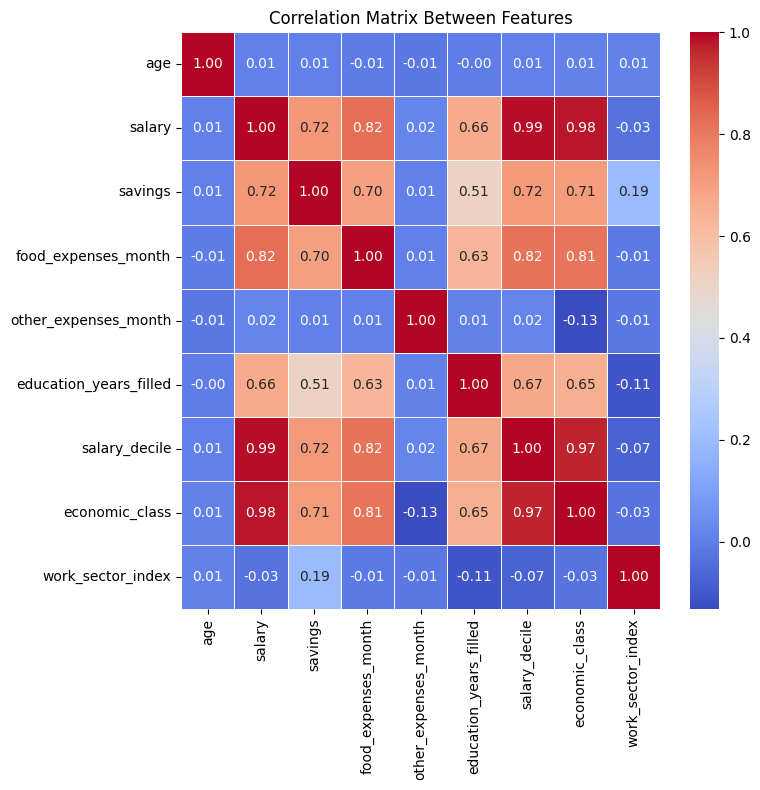

In [56]:
# שלב 1: ייבוא ספריות
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# שלב 2: הגדרת עמודות מספריות רלוונטיות בלבד
numeric_cols = [
    "age",
    "salary",
    "savings",
    "food_expenses_month",
    "other_expenses_month",
    "education_years_filled",
    "salary_decile",
    "economic_class",
    "work_sector_index"  # ← רק אם עבר StringIndexer
]

# שלב 3: סינון שורות עם null
df_no_nulls = df_with_indexed_sector.select(numeric_cols).dropna()

# שלב 4: יצירת וקטור פיצ'רים
vec_assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features_vector")
df_vec = vec_assembler.transform(df_no_nulls).select("features_vector")

# שלב 5: חישוב מטריצת קורלציה
correlation_matrix = Correlation.corr(df_vec, "features_vector", method="pearson").head()[0]

# שלב 6: המרה ל־Pandas DataFrame
corr_array = correlation_matrix.toArray()
corr_df = pd.DataFrame(corr_array, columns=numeric_cols, index=numeric_cols)

# שלב 7: הצגת מטריצה גרפית
plt.figure(figsize=(8, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Between Features")
plt.tight_layout()
plt.show()

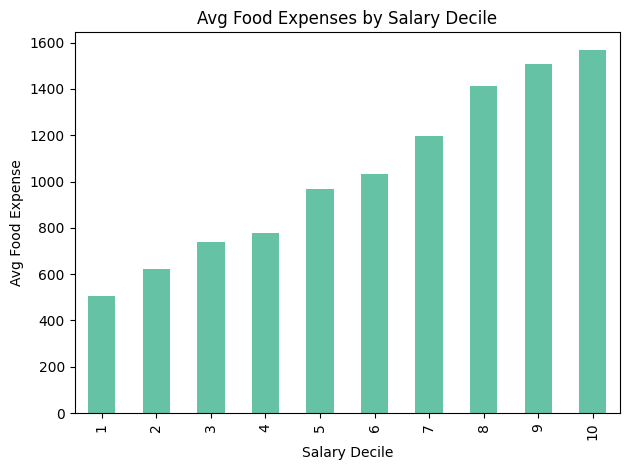

In [58]:
import pyspark.sql.functions as F

df_with_indexed_sector.groupBy("salary_decile") \
    .agg(F.avg("food_expenses_month").alias("avg_food_exp")) \
    .orderBy("salary_decile") \
    .toPandas().plot(
        x="salary_decile",
        y="avg_food_exp",
        kind="bar",
        title="Avg Food Expenses by Salary Decile",
        ylabel="Avg Food Expense",
        xlabel="Salary Decile",
        legend=False,
        color="#66c2a5"
    )
plt.tight_layout()
plt.show()

In [59]:
from pyspark.sql.functions import avg

# מחשבים ממוצע הוצאות אוכל לכל עשירון
food_avg_by_decile = df_with_indexed_sector.groupBy("salary_decile") \
    .agg(avg("food_expenses_month").alias("avg_food_exp"))

In [60]:
# מצטרפים לדאטה עם הממוצע לפי עשירון
df_filled_food = df_with_indexed_sector.join(food_avg_by_decile, on="salary_decile", how="left")

# ממלאים את הערכים החסרים בעמודת food_expenses_month
from pyspark.sql.functions import when, col, round

df_filled_food = df_filled_food.withColumn(
    "food_expenses_filled",
    when(col("food_expenses_month").isNull(), round(col("avg_food_exp"))).otherwise(col("food_expenses_month"))
)
df_filled_food = df_filled_food.drop("avg_food_exp")

In [61]:
columns_to_drop = [
    "education_years",              # המקורית, מכילה null
    "avg_edu_sector_decile",        # עזר למילוי בלבד
    "education_years_filled_raw",   # עותק לא מעוגל
    "most_common_sector",           # עזר למילוי סקטור
    "work_sector"                   # המקורית עם null, כבר מולאה
]

df_cleaned_final = df_with_indexed_sector.drop(*columns_to_drop)

In [62]:
from pyspark.sql.functions import col, count, when
import pandas as pd

total_rows = df_cleaned_final.count()

missing_counts = df_cleaned_final.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_cleaned_final.columns
])

missing_df = missing_counts.toPandas().T
missing_df.columns = ["missing_count"]
missing_df["missing_percent"] = (missing_df["missing_count"] / total_rows * 100).round(2)
missing_df.index.name = "column_name"
missing_df.reset_index(inplace=True)
missing_df.sort_values("missing_percent", ascending=False)

,column_name,missing_count,missing_percent
8,economic_class,46,0.77
2,age,18,0.30
5,food_expenses_month,18,0.30
6,zip_code,18,0.30
7,other_expenses_month,16,0.27
0,salary_decile,0,0.00
1,education_years_filled,0,0.00
3,salary,0,0.00
4,savings,0,0.00
9,work_sector_filled,0,0.00


In [63]:
from pyspark.sql import functions as F

food_stats_by_decile = df_cleaned_final.groupBy("salary_decile").agg(
    F.avg("food_expenses_month").alias("avg_food_expense"),
    F.stddev("food_expenses_month").alias("stddev_food_expense"),
    F.count("*").alias("count")
).orderBy("salary_decile")

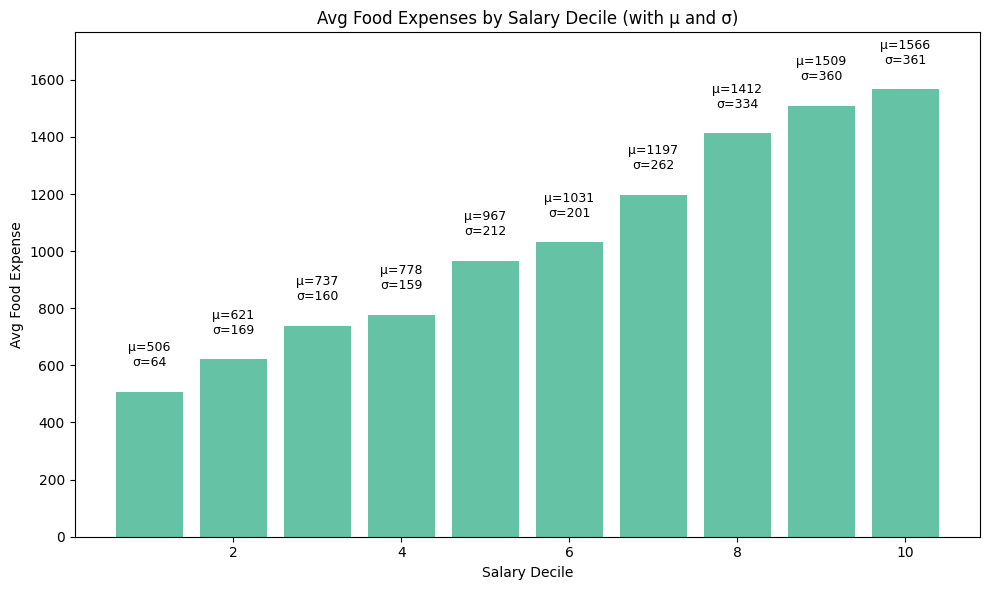

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# שלב 1: לחשב ממוצע + סטיית תקן לפי עשירון
food_stats_by_decile = df_cleaned_final.groupBy("salary_decile").agg(
    F.avg("food_expenses_month").alias("avg_food_expense"),
    F.stddev("food_expenses_month").alias("stddev_food_expense"),
    F.count("*").alias("count")
).orderBy("salary_decile")

# שלב 2: המרה ל־Pandas
food_stats_pd = food_stats_by_decile.toPandas()

# שלב 3: גרף עמודות עם שגיאה + טקסט
plt.figure(figsize=(10, 6))
bars = plt.bar(
    food_stats_pd["salary_decile"],
    food_stats_pd["avg_food_expense"],
    color="#66c2a5"
)

for bar, avg, std in zip(bars, food_stats_pd["avg_food_expense"], food_stats_pd["stddev_food_expense"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 80,  # גובה הטקסט מעל העמודה
        f"μ={avg:.0f}\nσ={std:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# הרחבת הציר האנכי כדי שיהיה מקום לכיתוב
plt.ylim(0, food_stats_pd["avg_food_expense"].max() + 200)

plt.xlabel("Salary Decile")
plt.ylabel("Avg Food Expense")
plt.title("Avg Food Expenses by Salary Decile (with μ and σ)")
plt.tight_layout()
plt.show()


In [65]:
import pyspark.sql.functions as F

# מחשבים ממוצע וסטיית תקן עבור הוצאות על אוכל לכל עשירון
food_exp_stats = df_with_indexed_sector.groupBy("salary_decile").agg(
    F.avg("food_expenses_month").alias("mu"),
    F.stddev("food_expenses_month").alias("sigma")
)

In [66]:
# מצרפים את הממוצע והסטיית תקן לדאטה פריים הראשי לפי salary_decile
df_with_stats = df_with_indexed_sector.join(food_exp_stats, on="salary_decile", how="left")

In [67]:
import numpy as np
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

# UDF לדגימה מנורמלית
@udf(returnType=DoubleType())
def sample_normal(mu, sigma):
    if mu is not None and sigma is not None:
        return float(np.random.normal(mu, sigma))
    return None

In [68]:
from pyspark.sql.functions import when, col

df_filled_food = df_with_stats.withColumn(
    "food_expenses_filled",
    when(
        col("food_expenses_month").isNull(),
        sample_normal(col("mu"), col("sigma"))
    ).otherwise(col("food_expenses_month"))
)

In [69]:
df_filled_food.filter("food_expenses_month is null") \
    .select("salary_decile", "food_expenses_filled") \
    .show(10)

+-------------+--------------------+
|salary_decile|food_expenses_filled|
+-------------+--------------------+
|            1|     545.82418937589|
|            6|   883.4306919845997|
|            3|    828.379751194029|
|            9|  1135.4559556051756|
|            4|   672.7495469376711|
|            4|  395.88534997632877|
|            8|  1239.0222390743531|
|            8|  1230.7596501379699|
|            8|  1498.1388556078107|
|            7|  1497.5944231453157|
+-------------+--------------------+
only showing top 10 rows



In [70]:
from pyspark.sql.functions import round as spark_round

# שלב 1: עיגול הערכים החדשים לפי חוקי המתמטיקה
df_rounded = df_filled_food.withColumn(
    "food_expenses_filled_rounded",
    spark_round("food_expenses_filled")
)

# שלב 2: מחיקת העמודה הישנה והעמודות הביניים, והחלפתה בעמודה החדשה
df_final = df_rounded \
    .drop("food_expenses_month", "food_expenses_filled") \
    .withColumnRenamed("food_expenses_filled_rounded", "food_expenses_month")

In [71]:
df_final.selectExpr("count(*) as total_rows", 
                    "sum(case when food_expenses_month is null then 1 else 0 end) as missing_after_fill").show()

+----------+------------------+
|total_rows|missing_after_fill|
+----------+------------------+
|      5986|                 0|
+----------+------------------+



In [72]:
from pyspark.sql.functions import round

df_filled_food = df_filled_food.withColumn(
    "food_expenses_filled",
    round(col("food_expenses_filled")).cast("int")
)
df_final = df_filled_food.drop("food_expenses_month") \
    .withColumnRenamed("food_expenses_filled", "food_expenses_month")

columns_to_drop = [
    "avg_edu_sector_decile",
    "education_years_filled_raw",
    "most_common_sector",
    "mu",
    "sigma",
    "work_sector",         
    "work_sector_filled",  
    "education_years"    
]

df_final = df_final.drop(*columns_to_drop)
df_final.show(10)

+-------------+----------------------+---+------+-------+--------+--------------------+--------------+-----------------+-------------------+
|salary_decile|education_years_filled|age|salary|savings|zip_code|other_expenses_month|economic_class|work_sector_index|food_expenses_month|
+-------------+----------------------+---+------+-------+--------+--------------------+--------------+-----------------+-------------------+
|            1|                  10.0| 48|  2045|   3920|   17673|                1360|             1|              4.0|                468|
|            6|                  15.0| 31|  5121|  27832|   32330|                1931|             4|              2.0|                640|
|            9|                  19.0| 35|  7580|  28599|   21555|                1732|             6|              3.0|               1960|
|            9|                  18.0| 29|  7612|  21559|   31315|                1294|             7|              1.0|               1155|
|            

In [73]:
from pyspark.sql.functions import col, when, sum as spark_sum
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# סופרים כמה שורות יש בדאטהפריים
total_rows = df_final.count()

# מחשבים כמות החוסרים בכל עמודה
missing_counts = df_final.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_final.columns
])

# ממירים ל־Pandas ומעבדים להצגה
missing_df = missing_counts.toPandas().T
missing_df.columns = ["missing_count"]
missing_df["missing_percent"] = (missing_df["missing_count"] / total_rows * 100).round(2)

# סידור הטבלה
missing_df.index.name = "column_name"
missing_df.reset_index(inplace=True)
missing_df = missing_df.sort_values("missing_percent", ascending=False)

# הצגת טבלה עם צבעים
missing_df.style.background_gradient(cmap='Blues').format({
    "missing_count": "{:,.0f}",
    "missing_percent": "{:.2f}%"
})

,column_name,missing_count,missing_percent
7,economic_class,46,0.77%
2,age,18,0.30%
5,zip_code,18,0.30%
6,other_expenses_month,16,0.27%
0,salary_decile,0,0.00%
1,education_years_filled,0,0.00%
3,salary,0,0.00%
4,savings,0,0.00%
8,work_sector_index,0,0.00%
9,food_expenses_month,0,0.00%


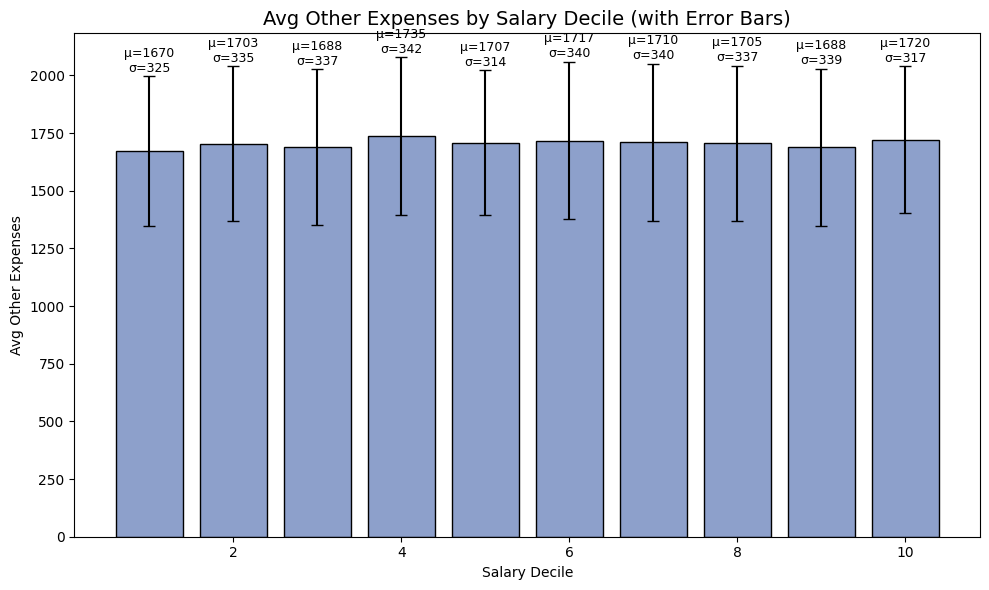

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# חישוב ממוצע וס״ת לפי עשירון
other_exp_stats = df_final.groupBy("salary_decile").agg(
    F.avg("other_expenses_month").alias("mean_other_exp"),
    F.stddev("other_expenses_month").alias("std_other_exp")
).orderBy("salary_decile")

# ל־Pandas
other_exp_stats_pd = other_exp_stats.toPandas()

# ציור הגרף
plt.figure(figsize=(10, 6))
plt.bar(
    other_exp_stats_pd["salary_decile"],
    other_exp_stats_pd["mean_other_exp"],
    yerr=other_exp_stats_pd["std_other_exp"],
    capsize=4,
    color="#8da0cb",
    edgecolor="black"
)

# הוספת טקסטים מעל כל עמודה
for idx, row in other_exp_stats_pd.iterrows():
    plt.text(
        row["salary_decile"],
        row["mean_other_exp"] + row["std_other_exp"] + 20,
        f"μ={int(row['mean_other_exp'])}\nσ={int(row['std_other_exp'])}",
        ha="center",
        fontsize=9
    )



plt.title("Avg Other Expenses by Salary Decile (with Error Bars)", fontsize=14)
plt.xlabel("Salary Decile")
plt.ylabel("Avg Other Expenses")
plt.tight_layout()
plt.show()

In [75]:
from pyspark.sql.functions import randn, when, col, lit, round

# שלב 1: חישוב תוחלת וסטיית תקן כללית
mu, sigma = df_final.select(
    F.mean("other_expenses_month"),
    F.stddev("other_expenses_month")
).first()

# שלב 2: מילוי ערכים חסרים בהתפלגות נורמלית ו־cast ל־int
df_final = df_final.withColumn(
    "other_expenses_month",
    when(
        col("other_expenses_month").isNull(),
        round(lit(mu) + randn() * lit(sigma)).cast("int")
    ).otherwise(col("other_expenses_month"))
)

In [76]:
# בודקים כמה ערכים חסרים נשארו בעמודה לאחר המילוי
df_final.select(
    F.count("*").alias("total_rows"),
    F.count(F.when(F.col("other_expenses_month").isNull(), 1)).alias("missing_after_fill")
).show()

+----------+------------------+
|total_rows|missing_after_fill|
+----------+------------------+
|      5986|                 0|
+----------+------------------+



In [77]:
from pyspark.sql.functions import col, when, count
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# סופרים את מספר השורות הכולל
total_rows = df_final.count()

# בודקים כמה ערכים חסרים יש בכל עמודה
missing_counts = df_final.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_final.columns
])

# ממירים ל־Pandas ומסדרים טבלה
missing_df = missing_counts.toPandas().T
missing_df.columns = ["missing_count"]
missing_df["missing_percent"] = (missing_df["missing_count"] / total_rows * 100).round(2)
missing_df.index.name = "column_name"
missing_df.reset_index(inplace=True)

# מיון לפי אחוזים יורדים
missing_df = missing_df.sort_values("missing_percent", ascending=False)

# מציג טבלה עם צבעוניות
missing_df.style.background_gradient(cmap="Reds").format({
    "missing_count": "{:.0f}",
    "missing_percent": "{:.2f}%"
})

,column_name,missing_count,missing_percent
7,economic_class,46,0.77%
2,age,18,0.30%
5,zip_code,18,0.30%
0,salary_decile,0,0.00%
1,education_years_filled,0,0.00%
3,salary,0,0.00%
4,savings,0,0.00%
6,other_expenses_month,0,0.00%
8,work_sector_index,0,0.00%
9,food_expenses_month,0,0.00%


In [79]:
from pyspark.sql.functions import when, col

# סינון ערכים לא הגיוניים
df_final = df_final.withColumn(
    "age",
    when((col("age") < 18) | (col("age") > 100), None).otherwise(col("age"))
)

In [80]:
"age" in df_with_indexed_sector.columns

True

In [81]:
from pyspark.sql.functions import monotonically_increasing_id

# מוסיפים אינדקס זמני לשני הדאטהפריימים
df_with_index = df_final.withColumn("row_id", monotonically_increasing_id())
df_age_orig = df_with_indexed_sector.select("age").withColumn("row_id", monotonically_increasing_id())

# מחברים לפי row_id
df_replaced = df_with_index.drop("age").join(df_age_orig, on="row_id", how="inner")

# מסירים את העמודה העזר row_id
df_final = df_replaced.drop("row_id")

In [82]:
from pyspark.sql.functions import col, sum as Fsum

# רשימת עמודות לבדיקה
columns = df_final.columns

# יצירת DataFrame שמכיל מספר ואחוז החוסרים לכל עמודה
missing_df = df_final.select([
    Fsum(col(c).isNull().cast("int")).alias(c) for c in columns
]).toPandas().T.reset_index()

missing_df.columns = ['column_name', 'missing_count']
total_rows = df_final.count()
missing_df['missing_percent'] = (missing_df['missing_count'] / total_rows * 100).round(2)

# הצגה מסודרת (ממויינת)
missing_df = missing_df.sort_values(by='missing_count', ascending=False)
missing_df.style.background_gradient(cmap='Blues').format({
    "missing_percent": "{:.2f}%",
    "missing_count": "{:.0f}"
})

,column_name,missing_count,missing_percent
6,economic_class,46,0.77%
4,zip_code,18,0.30%
9,age,18,0.30%
0,salary_decile,0,0.00%
1,education_years_filled,0,0.00%
2,salary,0,0.00%
3,savings,0,0.00%
5,other_expenses_month,0,0.00%
7,work_sector_index,0,0.00%
8,food_expenses_month,0,0.00%


In [83]:
from pyspark.sql.functions import col, when, lit, randn, round as spark_round, mean, stddev

# חישוב תוחלת וסטיית תקן רק מהערכים התקניים (כלומר לא null)
age_stats = df_final.filter(col("age").isNotNull()).agg(
    mean("age").alias("mu_age"),
    stddev("age").alias("std_age")
).first()

mu_age = age_stats["mu_age"]
std_age = age_stats["std_age"]

# מילוי רק של הערכים החסרים
df_final = df_final.withColumn(
    "age",
    when(
        col("age").isNull(),
        spark_round(lit(mu_age) + randn() * lit(std_age)).cast("int")
    ).otherwise(col("age"))
)

In [84]:
from pyspark.sql.functions import col, substring

# אם zip_code הוא מספר, נמיר אותו קודם למחרוזת
df_final = df_final.withColumn("zip_prefix", substring(col("zip_code").cast("string"), 1, 3))

In [85]:
df_final.stat.crosstab("zip_prefix", "work_sector_index").show(truncate=False)

+----------------------------+---+---+---+---+---+
|zip_prefix_work_sector_index|0.0|1.0|2.0|3.0|4.0|
+----------------------------+---+---+---+---+---+
|296                         |5  |5  |5  |3  |2  |
|307                         |7  |3  |5  |3  |3  |
|169                         |6  |6  |2  |5  |6  |
|205                         |4  |2  |2  |2  |1  |
|334                         |4  |6  |5  |4  |5  |
|272                         |3  |5  |1  |3  |7  |
|282                         |5  |4  |5  |2  |7  |
|234                         |4  |5  |3  |2  |5  |
|232                         |3  |5  |4  |7  |5  |
|383                         |4  |1  |0  |5  |4  |
|317                         |3  |2  |3  |5  |4  |
|200                         |7  |5  |7  |4  |3  |
|388                         |7  |5  |2  |2  |8  |
|279                         |4  |4  |4  |3  |4  |
|415                         |1  |12 |7  |4  |4  |
|387                         |4  |5  |3  |3  |6  |
|351                         |3

In [86]:
from pyspark.sql import functions as F

# ממוצע עשירון שכר לפי zip_prefix, מהגבוה לנמוך
df_final.groupBy("zip_prefix") \
    .agg(F.avg("salary_decile").alias("avg_salary_decile")) \
    .orderBy(F.desc("avg_salary_decile")) \
    .show(20)

+----------+------------------+
|zip_prefix| avg_salary_decile|
+----------+------------------+
|       198|            7.5625|
|       254| 7.277777777777778|
|       357| 7.222222222222222|
|       199| 7.037037037037037|
|       322|               7.0|
|       228| 6.928571428571429|
|       206| 6.904761904761905|
|       219| 6.888888888888889|
|       354| 6.809523809523809|
|       304| 6.791666666666667|
|       211| 6.785714285714286|
|       374| 6.764705882352941|
|       231|6.7272727272727275|
|       230| 6.647058823529412|
|       380| 6.571428571428571|
|       382| 6.571428571428571|
|       187| 6.545454545454546|
|       341|               6.5|
|       361| 6.481481481481482|
|       216| 6.387096774193548|
+----------+------------------+
only showing top 20 rows



In [87]:
df_final.filter(F.col("zip_code").isNull()).show(truncate=False)
df_final.filter(F.col("zip_code").isNull()).count()

+-------------+----------------------+------+-------+--------+--------------------+--------------+-----------------+-------------------+---+----------+
|salary_decile|education_years_filled|salary|savings|zip_code|other_expenses_month|economic_class|work_sector_index|food_expenses_month|age|zip_prefix|
+-------------+----------------------+------+-------+--------+--------------------+--------------+-----------------+-------------------+---+----------+
|1            |13.0                  |2283  |6212   |NULL    |1646                |1             |4.0              |441                |36 |NULL      |
|6            |14.0                  |5264  |25009  |NULL    |1684                |4             |2.0              |1178               |34 |NULL      |
|6            |18.0                  |5223  |12928  |NULL    |1902                |4             |1.0              |1198               |28 |NULL      |
|6            |16.0                  |5378  |26815  |NULL    |1947                |4    

18

In [88]:
df_final.select("zip_prefix").distinct().count()

267

In [89]:
from pyspark.sql.functions import col, count

# טבלת שכיחויות בין zip_prefix לעשירון שכר
zip_salary_dist = (
    df_final.groupBy("salary_decile", "zip_prefix")
    .agg(count("*").alias("count"))
    .orderBy("salary_decile", col("count").desc())
)

zip_salary_dist.show(50)

+-------------+----------+-----+
|salary_decile|zip_prefix|count|
+-------------+----------+-----+
|            1|       172|    6|
|            1|       265|    6|
|            1|       201|    6|
|            1|       377|    6|
|            1|       381|    6|
|            1|       312|    6|
|            1|       329|    6|
|            1|       365|    6|
|            1|       408|    6|
|            1|       400|    6|
|            1|       405|    6|
|            1|       325|    5|
|            1|       270|    5|
|            1|       157|    5|
|            1|       263|    5|
|            1|       352|    5|
|            1|       170|    5|
|            1|       176|    5|
|            1|       227|    5|
|            1|       294|    5|
|            1|       272|    5|
|            1|       287|    5|
|            1|       309|    5|
|            1|       212|    5|
|            1|       291|    5|
|            1|       416|    5|
|            1|       401|    5|
|         

In [90]:
from pyspark.sql.functions import substring, col

df_final = df_final.withColumn(
    "zip_prefix1",
    substring(col("zip_code").cast("string"), 1, 1)
)

In [91]:
zip_total_counts = df_final.groupBy("zip_prefix1").count().withColumnRenamed("count", "total_per_prefix")

In [92]:
zip_decile_counts = df_final.groupBy("zip_prefix1", "salary_decile") \
    .count().withColumnRenamed("count", "count_per_decile")

In [95]:
from pyspark.sql.functions import col

df_final = df_final.withColumn(
    "net_savings",
    col("salary") - (col("food_expenses_month") + col("other_expenses_month"))
)

In [98]:
from pyspark.sql.functions import col, when

# נזהה את כל העמודות בדאטהפריים
columns = df_final.columns

# נבנה עותק שבו כל ערך null מוחלף ב־-1 (למספרים)
df_final_filled = df_final

for c in columns:
    df_final_filled = df_final_filled.withColumn(
        c,
        when(col(c).isNull(), -1).otherwise(col(c))
    )

In [99]:
from pyspark.sql.functions import col, count, when, isnan

# סך הכל שורות בדאטה
total_rows = df_final.count()

# עבור כל עמודה – נחשב כמה ערכים חסרים יש (null)
missing_stats = df_final.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_final.columns
])

# המרת התוצאה לפורמט ארוך ונוח
missing_df = missing_stats.toPandas().T.reset_index()
missing_df.columns = ['column', 'missing_count']
missing_df['missing_percent'] = (missing_df['missing_count'] / total_rows * 100).round(2)

# מיון לפי כמות חוסרים
missing_df = missing_df.sort_values(by='missing_count', ascending=False)

# הצגה
missing_df

,column,missing_count,missing_percent
6,economic_class,46,0.77
4,zip_code,18,0.30
10,zip_prefix,18,0.30
11,zip_prefix1,18,0.30
0,salary_decile,0,0.00
1,education_years_filled,0,0.00
2,salary,0,0.00
3,savings,0,0.00
5,other_expenses_month,0,0.00
7,work_sector_index,0,0.00


In [101]:
from pyspark.sql.functions import col, when, lit

df_final = df_final.withColumn(
    "zip_code", 
    when(col("zip_code").isNull(), lit(-1)).otherwise(col("zip_code"))
)

In [102]:
columns_to_drop = ["zip_prefix", "zip_prefix1", "zip_prefix2"]
df_final = df_final.drop(*columns_to_drop)

In [106]:
df_final.columns
df_final.write \
    .option("header", True) \
    .mode("overwrite") \
    .csv("hdfs://namenode:8020/user/mambauser/df_final_csv")

2025-11-15T08:28:09,829 ERROR org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
2025-11-15T08:28:09,853 ERROR org.apache.spark.rpc.netty.Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291) ~[spark-core_2.12-3.5.3.jar:3.5.3]
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981) ~[spark-core_2.12-3.5.3.jar:3.5.3]
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165) ~[spark-core_2.12-3.5.3.jar:3.5.3]
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263) ~[spark-core_2.12-3.5.3.jar:3.5.3]
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint$$anonfun$receive$1.applyOrEl